In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [9]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1070, 8)
X_test : (268, 8)
y_train: (1070,)
y_test : (268,)


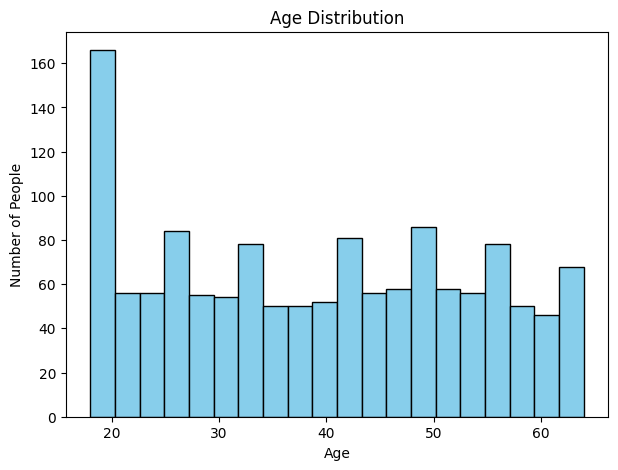

In [12]:
plt.figure(figsize=(7,5))
plt.hist(df["age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.show()

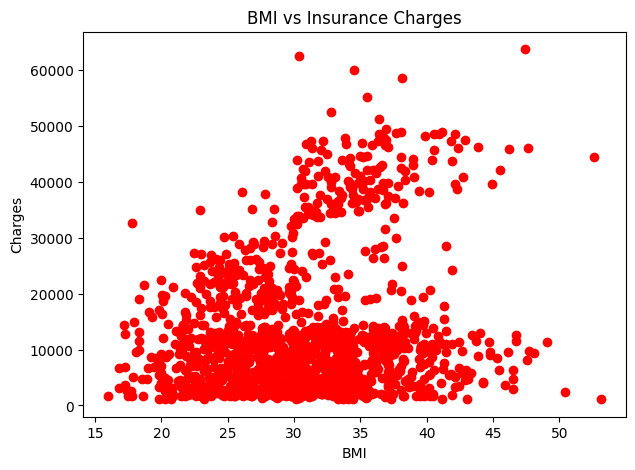

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(df["bmi"], df["charges"], color="red")
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

# Question: Bias-Variance Tradeoff Visualization

## Objective

The purpose of this task is to visualize the bias-variance tradeoff by comparing training error and test error for models with different levels of complexity.

In this task, polynomial regression models with increasing degrees are used. The graph shows how model complexity affects performance. A simple model may have high bias and cause underfitting, while a very complex model may have high variance and cause overfitting.

By comparing training and test errors, we can understand the point where the model achieves a good balance between learning patterns and avoiding overfitting.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [15]:
np.random.seed(42)

X = np.sort(5 * np.random.rand(100, 1), axis=0)

y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [16]:
degrees = range(1, 10)

train_errors = []
test_errors = []

for degree in degrees:
    
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    
    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_errors.append(
        mean_squared_error(y_train, train_prediction)
    )

    test_errors.append(
        mean_squared_error(y_test, test_prediction)
    )

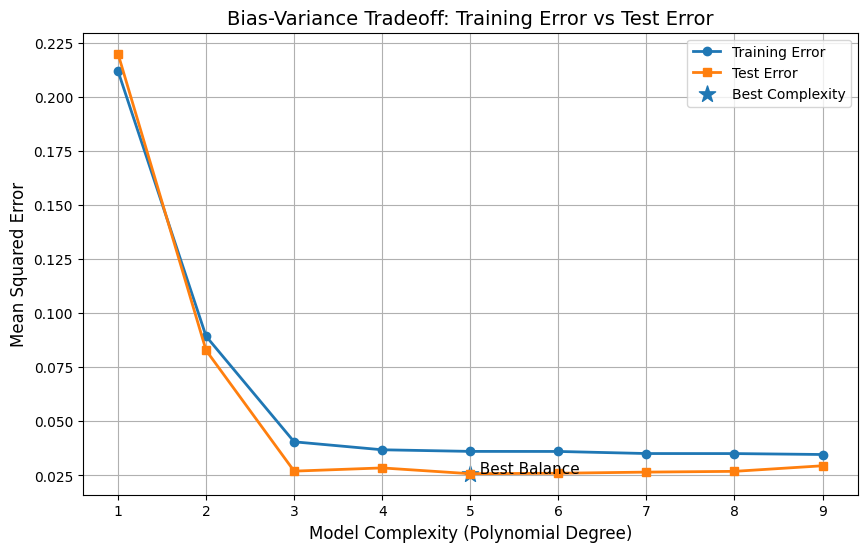

In [17]:
plt.figure(figsize=(10,6))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    linewidth=2,
    label="Training Error"
)

plt.plot(
    degrees,
    test_errors,
    marker="s",
    linewidth=2,
    label="Test Error"
)

# Best model point
best_degree = degrees[np.argmin(test_errors)]
best_error = min(test_errors)

plt.scatter(
    best_degree,
    best_error,
    s=150,
    marker="*",
    label="Best Complexity"
)

plt.text(
    best_degree,
    best_error,
    "  Best Balance",
    fontsize=11
)

plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=12)
plt.ylabel("Mean Squared Error", fontsize=12)

plt.title(
    "Bias-Variance Tradeoff: Training Error vs Test Error",
    fontsize=14
)

plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.show()

# Load and Prepare Dataset for Modeling

## Objective

The purpose of this task is to load a dataset and prepare it for machine learning modeling. Data preparation includes checking the dataset, handling missing values, selecting features, and dividing the data into training and testing sets.

In [18]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [19]:
# Load built-in diabetes dataset
data = load_diabetes()

# Convert data into DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df["target"] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [25]:
# Input features
X = df.drop("target", axis=1)

# Output target
y = df["target"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


The dataset was successfully loaded and prepared for modeling. The data was checked for missing values and divided into input features and target values. Finally, the dataset was split into training and testing sets so that the model can learn from training data and evaluate its performance on unseen test data.

# Train Linear Regression Model

## Objective

The purpose of this task is to split the dataset into training and testing sets and train a Linear Regression model using scikit-learn. The model learns patterns from the training data and uses them to make predictions on new data.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


In [28]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model training completed successfully")

Model training completed successfully


The dataset was divided into training and testing sets. The Linear Regression model was then trained using the training data. During training, the model learns the relationship between input features and the target value by calculating the best coefficients.

# Model Evaluation

## Objective

The purpose of this task is to evaluate the performance of the Linear Regression model using evaluation metrics. Mean Squared Error (MSE) and R² score are used to measure how accurately the model predicts the target values.

In [31]:
# Predict values using test data
y_pred = model.predict(X_test)

y_pred[:5]

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872])

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 2900.1936284934804
R2 Score: 0.4526027629719196


## Interpretation of Results

Mean Squared Error (MSE) shows the average difference between actual and predicted values. A lower MSE value means that the model predictions are closer to the actual values.

R² score shows how well the model explains the relationship between input features and the target value. A value closer to 1 indicates better model performance.

The evaluation results show how accurately the Linear Regression model can predict outcomes on unseen test data.

# Visualization of Actual vs Predicted Values

## Objective

The purpose of this task is to visualize the performance of the Linear Regression model by comparing actual target values with predicted values. This graph helps us understand how closely the model predictions match the real values.

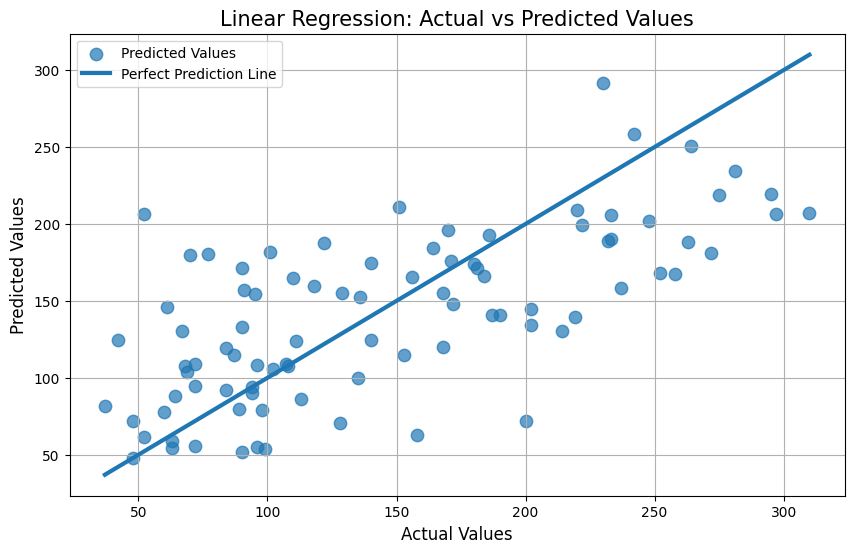

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# Scatter plot of actual and predicted values
plt.scatter(
    y_test,
    y_pred,
    s=80,
    alpha=0.7,
    label="Predicted Values"
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=3,
    label="Perfect Prediction Line"
)

plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)

plt.title(
    "Linear Regression: Actual vs Predicted Values",
    fontsize=15
)

plt.legend()
plt.grid(True)

plt.show()

## Interpretation

The graph compares the actual values from the dataset with the values predicted by the Linear Regression model.

Points closer to the diagonal line show that the model predictions are close to the actual values. If most points are near the line, the model has good prediction performance. A large distance from the line indicates prediction errors.

This visualization helps to understand how accurately the model is predicting results on unseen test data.

# Data Preprocessing of Raw CSV Dataset

## Objective

The purpose of this task is to load a raw CSV dataset and prepare it for machine learning. The data is cleaned by handling missing values and converting categorical columns into numerical form so that it can be used for modeling.

In [34]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [35]:
# Check missing values
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [40]:
# Check categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index([], dtype='str')


In [41]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
encoder = LabelEncoder()

# Example categorical column encoding
df["sex_encoded"] = encoder.fit_transform(df["sex"])

# Display result
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,sex_encoded
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0,0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0,0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0,0


## Conclusion

The raw CSV dataset was successfully loaded and prepared for machine learning. Missing values were checked and handled to improve data quality. The dataset was also checked for categorical columns, but no categorical features were found because all columns were already in numerical form. Therefore, encoding was not required for this dataset.

After preprocessing, the dataset became ready for further modeling.

# Creating a Function for Train-Test Split

## Objective

The purpose of this task is to create a function that can split any dataset into training and testing sets based on a given split ratio. The function also displays the shape of the resulting datasets.

In [42]:
from sklearn.model_selection import train_test_split

def split_dataset(X, y, test_ratio):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_ratio,
        random_state=42
    )
    
    print("Training Features Shape:", X_train.shape)
    print("Testing Features Shape:", X_test.shape)
    print("Training Target Shape:", y_train.shape)
    print("Testing Target Shape:", y_test.shape)
    
    return X_train, X_test, y_train, y_test

In [43]:
# Using the function

X_train, X_test, y_train, y_test = split_dataset(
    X,
    y,
    0.2
)

Training Features Shape: (353, 10)
Testing Features Shape: (89, 10)
Training Target Shape: (353,)
Testing Target Shape: (89,)


## Result

The function successfully divided the dataset into training and testing sets. The printed shapes show the number of samples and features available in each set. This function can be reused with different datasets and split ratios.

# Comparing Different Train-Test Split Ratios

## Objective

The purpose of this task is to train the same Linear Regression model using different train-test split ratios and compare the performance using evaluation metrics.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Different split ratios
ratios = [0.4, 0.2, 0.1]

results = []

for ratio in ratios:
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=ratio,
        random_state=42
    )
    
    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append([
        f"{int((1-ratio)*100)}/{int(ratio*100)}",
        mse,
        r2
    ])

# Create comparison table
comparison_table = pd.DataFrame(
    results,
    columns=["Train/Test Split", "Mean Squared Error", "R2 Score"]
)

comparison_table

,Train/Test Split,Mean Squared Error,R2 Score
0,60/40,2832.996240,0.515744
1,80/20,2900.193628,0.452603
2,90/10,2743.911238,0.551420


## Interpretation

The table compares the performance of the Linear Regression model using different train-test split ratios.

Mean Squared Error shows the prediction error, where lower values indicate better performance. R² score shows how well the model explains the data, where a value closer to 1 indicates better performance.

Different split ratios can produce slightly different results because the model is trained and tested on different amounts of data.

# K-Fold Cross Validation

## Objective

The purpose of this task is to evaluate the Linear Regression model using k-fold cross-validation. Cross-validation helps check how well the model performs on different parts of the dataset.

In [45]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Create Linear Regression model
model = LinearRegression()

# Perform 5-fold cross validation
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

# Display scores
print("Cross Validation Scores:", scores)

# Average score
average_score = np.mean(scores)

print("Average R2 Score:", average_score)

Cross Validation Scores: [0.42955615 0.52259939 0.48268054 0.42649776 0.55024834]
Average R2 Score: 0.48231643590864215


## Interpretation

The model was evaluated using 5-fold cross-validation. The dataset was divided into five parts, and the model was trained and tested multiple times using different combinations of data.

The average R² score represents the overall performance of the model. A higher R² score indicates that the model can explain more variation in the target values and performs better on unseen data.

# Learning Curve Analysis

## Objective

The purpose of this task is to plot a learning curve to compare training and test performance as the training dataset size increases. It helps to understand whether the model is overfitting or underfitting.

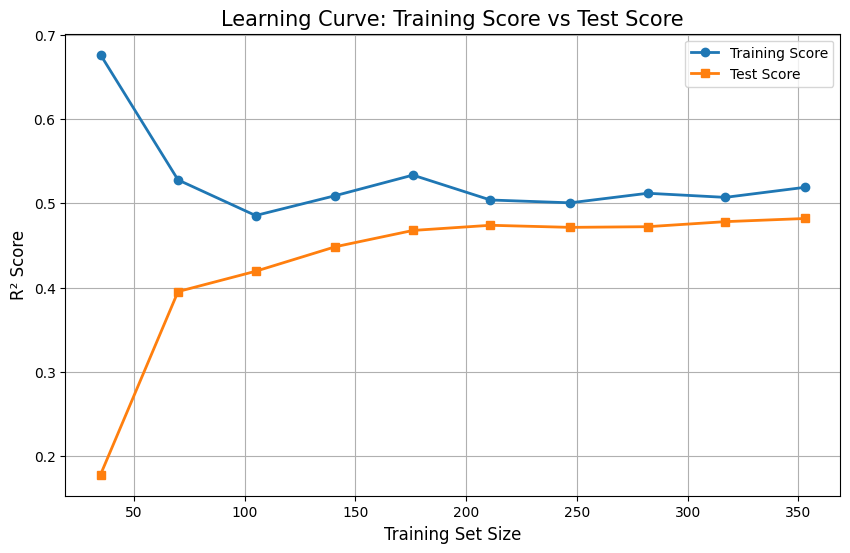

In [46]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Create model
model = LinearRegression()

# Calculate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate average scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training Score"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="s",
    linewidth=2,
    label="Test Score"
)

plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("R² Score", fontsize=12)

plt.title(
    "Learning Curve: Training Score vs Test Score",
    fontsize=15
)

plt.legend()
plt.grid(True)

plt.show()

## Interpretation

The learning curve shows how model performance changes when more training data is added.

If the training score is high but the test score is much lower, it indicates overfitting. The model learns the training data very well but cannot perform well on new data.

If both training and test scores are low and close to each other, it indicates underfitting. The model is too simple and cannot learn important patterns.

A good model should have training and test scores that are close to each other and improve as the training data increases.

# Refactoring Code into Reusable Functions

## Objective

The purpose of this task is to organize the machine learning workflow into reusable functions. Functions make the code cleaner, easier to understand, and reusable for different datasets.

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load dataset function
def load_data(file_path):
    data = pd.read_csv(file_path)
    return data


# Split data function
def split_data(X, y, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )
    return X_train, X_test, y_train, y_test


# Train model function
def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


# Evaluate model function
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print("Mean Squared Error:", mse)
    print("R2 Score:", r2)

    return mse, r2

In [50]:
from sklearn.datasets import load_diabetes
import pandas as pd

def load_data():
    data = load_diabetes()
    
    df = pd.DataFrame(
        data.data,
        columns=data.feature_names
    )
    
    df["target"] = data.target
    
    return df

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split data
X_train, X_test, y_train, y_test = split_data(X, y)

# Train model
model = train_model(X_train, y_train)

# Evaluate model
evaluate_model(model, X_test, y_test)

Mean Squared Error: 2900.193628493463
R2 Score: 0.4526027629719229


(2900.193628493463, 0.4526027629719229)

## Conclusion

The notebook code was successfully refactored into reusable functions. Each function performs a specific task such as loading data, splitting data, training the model, and evaluating performance. This approach makes the code more organized and easier to maintain.

# Polynomial Regression Comparison

## Objective

The purpose of this task is to extend the Linear Regression model by adding polynomial features and compare its performance with the simple linear model. Polynomial regression can learn more complex relationships between features and the target value.

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train linear model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Predictions
linear_pred = linear_model.predict(X_test)

# Evaluation
linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MSE:", linear_mse)
print("R2 Score:", linear_r2)

Linear Regression
MSE: 2900.193628493463
R2 Score: 0.4526027629719229


In [52]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train polynomial model
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

# Predictions
poly_pred = poly_model.predict(X_test_poly)

# Evaluation
poly_mse = mean_squared_error(y_test, poly_pred)
poly_r2 = r2_score(y_test, poly_pred)

print("Polynomial Regression")
print("MSE:", poly_mse)
print("R2 Score:", poly_r2)

Polynomial Regression
MSE: 3096.0283073442765
R2 Score: 0.4156399336407993


In [53]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "MSE": [linear_mse, poly_mse],
    "R2 Score": [linear_r2, poly_r2]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,2900.193628,0.452603
1,Polynomial Regression,3096.028307,0.415640


## Result Explanation

The performance of Linear Regression and Polynomial Regression was compared using MSE and R² score.

If the polynomial model gives better test performance than the linear model, it means it can capture more complex patterns and generalizes better.

If the polynomial model performs very well on training data but poorly on test data, it indicates overfitting because the model learns unnecessary details from the training data.

If both models perform poorly, it indicates underfitting. The best model is the one that gives good performance on unseen test data without learning unnecessary patterns.